In [233]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2"

In [234]:
import torch
from custom_vision_transformer import vit_custom
from training_utils import get_data_loaders
from types import SimpleNamespace
import matplotlib.pyplot as plt
import numpy as np

In [235]:
params = SimpleNamespace(
    gpu_idx=1,
    num_classes=100,
    img_size=224,
    batch_size=16,
)

In [236]:
print("Number of visible GPUs :", torch.cuda.device_count())

torch.cuda.set_device(params.gpu_idx)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}:{torch.cuda.current_device()} {torch.cuda.get_device_name(torch.cuda.current_device())}" if torch.cuda.is_available() else "CPU")

Number of visible GPUs : 3
Device: cuda:1 NVIDIA RTX A4500


In [237]:
model = vit_custom(num_classes=params.num_classes, image_size=params.img_size, attention_bias=True, attention_mask=False).to(device)
checkpoint = torch.load("training_checkpoints/checkpoint5/vit_custom_epoch_50.pth")
model.load_state_dict(checkpoint["model_state_dict"])
model.eval();

In [238]:
train_loader, val_loader = get_data_loaders(batch_size=params.batch_size, persistent_workers=False, shuffle_val=True)

imgs, labels = next(iter(val_loader))
tensor = imgs[0].unsqueeze(0).to(device)  # add batch dimension and move to device

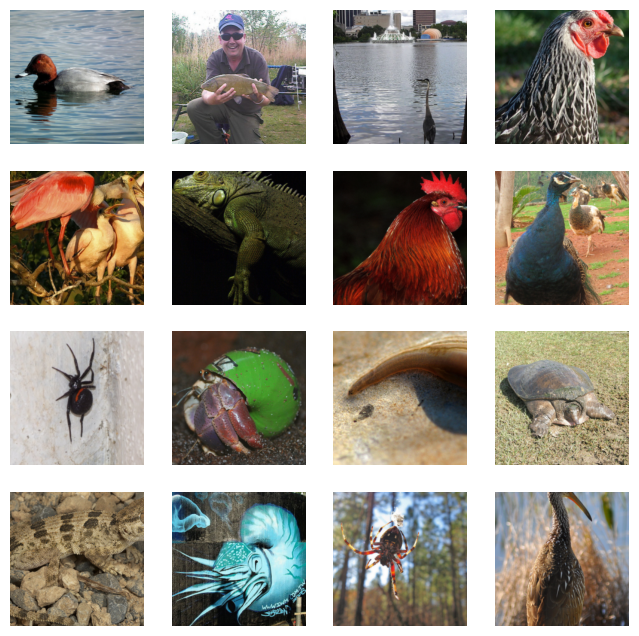

In [239]:
# display some images
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
sample_imgs = imgs[:16]  # take first 16 images
sample_imgs = sample_imgs.cpu().permute(0, 2, 3, 1) * torch.tensor(std).view(1, 1, 1, 3) + torch.tensor(mean).view(1, 1, 1, 3)
sample_imgs = torch.clamp(sample_imgs, 0, 1).numpy()
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_imgs[i])
    ax.axis('off')
plt.show()

In [240]:
activations = {
    "b": {},
    "attn": {}
}

# --- Fonctions hook ---
def make_b_hook(name):
    def hook(module, input, output):
        activations["b"][name] = output.detach()
    return hook

def make_attn_hook(name):
    def hook(module, input, output):
        out, attn = output
        activations["attn"][name] = attn.detach()
    return hook

# --- Nettoyer tous les hooks existants sur tous les modules ---
for module in model.modules():
    module._forward_hooks.clear()

# --- Ajouter les hooks ---
for name, module in model.named_modules():
    if name.endswith(".attention.b"):
        module.register_forward_hook(make_b_hook(name))
    elif name.endswith(".attention"):
        module.register_forward_hook(make_attn_hook(name))


# for k, v in activations["attn"].items():
#     print(k, v.shape)

# for k, v in activations["b"].items():
#     print(k, v.shape)

In [241]:
_ = model(tensor.to(device))

attention_list = [v for k, v in activations["attn"].items()]
b_list = [v for k, v in activations["b"].items()]

In [242]:
output_dir = "attention_maps/attention_vs_bias"
os.makedirs(output_dir, exist_ok=True)

for layer_idx, (attn_l, b_l) in enumerate(zip(attention_list, b_list)):
    attn = attn_l[0]  # [heads, tokens, tokens]
    b = b_l[0]        # [tokens, heads]

    rows, cols = 3, 6
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    fig.suptitle(f"Layer {layer_idx}: attention (top), bias (middle), attention + b<0 overlay (bottom)", fontsize=14)

    n = min(cols, attn.shape[0], b.shape[-1])
    attn_imgs = [attn[h].cpu().numpy() for h in range(n)]
    bias_imgs = [torch.softmax(b[:, h].view(1, -1), dim=-1).repeat(b.shape[0], 1).cpu().numpy() for h in range(n)]

    for row, (imgs, prefix) in enumerate([(attn_imgs, "Head"), (bias_imgs, "Bias")]):
        for head in range(cols):
            ax = axes[row, head]
            if head < n:
                vmin, vmax = attn_imgs[head].min(), attn_imgs[head].max()
                ax.imshow(imgs[head], cmap="viridis", vmin=vmin, vmax=vmax)
                ax.set_title(f"{prefix} {head}")
            ax.axis("off")

    for head in range(cols):
        ax = axes[2, head]
        if head < n:
            vmin, vmax = attn_imgs[head].min(), attn_imgs[head].max()
            neg = (b[:, head] < 0).cpu().numpy()
            mask = np.repeat(neg[None, :], attn_imgs[head].shape[0], axis=0)
            ax.imshow(attn_imgs[head], cmap="viridis", vmin=vmin, vmax=vmax)
            ax.imshow(np.ma.masked_where(~mask, mask), cmap="Reds", alpha=0.35, interpolation="nearest")
            ax.set_title(f"Head {head}: {neg.sum()}/{len(neg)} trunc")
        ax.axis("off")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/layer_{layer_idx}_attn_bias_grid.png")
    plt.close(fig)

In [243]:
output_dir = "attention_maps/scatter_plots"
os.makedirs(output_dir, exist_ok=True)

for i in range(len(attention_list)):
    num_layer = i
    attention_at_layer = attention_list[num_layer][0]
    b_at_layer = b_list[num_layer][0]

    n_heads = attention_at_layer.shape[0]  # nombre de têtes
    rows, cols = 2, 3  # grille 2x3

    plt.figure(figsize=(15, 8))  # taille globale de la figure
    plt.suptitle(f"Layer {num_layer} - Bias vs Attention measure", fontsize=16)

    for head in range(n_heads):
        b_head = b_at_layer[:, head]
        attention_map_head = attention_at_layer[head, :, :]
        attention_measure_head = attention_map_head.sum(dim=0)  # somme des poids d'attention pour chaque token

        plt.subplot(rows, cols, head + 1)  # position dans la grille
        plt.scatter(b_head.cpu(), attention_measure_head.cpu())
        plt.title(f"Head {head}")
        plt.xlabel("Bias")
        plt.ylabel("Attention measure")
        plt.grid(True)

    plt.tight_layout()  # ajuste les sous-figures pour éviter le chevauchement
    plt.savefig(f"{output_dir}/layer_{num_layer}.png")
    plt.close()

In [244]:
# nombre moyen de colonnes tronquées (biais < 0) par layer, moyenné sur le batch
avg_trunc_per_layer = [
    ((b_layer < 0).float().sum(dim=1).mean(dim=1)).mean().item()
    for b_layer in b_list
]

plt.figure(figsize=(8, 4))
plt.plot(avg_trunc_per_layer, marker="o")
plt.xlabel("Layer")
plt.ylabel("Nb moyen de colonnes tronquées")
plt.title("Nombre moyen de colonnes tronquées (biais < 0) par layer")
plt.xticks(range(len(avg_trunc_per_layer)))
plt.grid(True)
plt.tight_layout()
plt.savefig("attention_maps/avg_truncated_cols_per_layer.png")
plt.close()

In [245]:
# Grille simple par layer: 1) attention, 2) biais, 3) residu
output_dir = "attention_maps/attn_bias_residual_grid"
os.makedirs(output_dir, exist_ok=True)

for layer_idx, (attn_l, b_l) in enumerate(zip(attention_list, b_list)):
    attn = attn_l[0]  # [heads, tokens, tokens]
    b = b_l[0]        # [tokens, heads]

    rows, cols = 3, 6
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    fig.suptitle(f"Layer {layer_idx}: attention / bias / residual", fontsize=14)

    n = min(cols, attn.shape[0], b.shape[-1])
    attn_imgs = [attn[h].cpu().numpy() for h in range(n)]
    bias_imgs = [torch.softmax(b[:, h].view(1, -1), dim=-1).repeat(b.shape[0], 1).cpu().numpy() for h in range(n)]
    residual_imgs = [a - bi for a, bi in zip(attn_imgs, bias_imgs)]

    row_specs = [(attn_imgs, "Head"), (bias_imgs, "Bias"), (residual_imgs, "Residual")]
    for row, (imgs, prefix) in enumerate(row_specs):
        for head in range(cols):
            ax = axes[row, head]
            if head < n:
                if row < 2:
                    vmin, vmax = attn_imgs[head].min(), attn_imgs[head].max()
                    ax.imshow(imgs[head], cmap="viridis", vmin=vmin, vmax=vmax)
                else:
                    # Residual contains positive and negative values: center color scale at 0
                    res_abs = np.max(np.abs(imgs[head])) + 1e-12
                    ax.imshow(imgs[head], cmap="RdBu_r", vmin=-res_abs, vmax=res_abs)
                ax.set_title(f"{prefix} {head}")
            ax.axis("off")

    fig.tight_layout(rect=[0, 0, 1, 0.95])
    fig.savefig(f"{output_dir}/layer_{layer_idx}_attn_bias_residual_grid.png")
    plt.close(fig)